<a href="https://colab.research.google.com/github/Daniellopezram/Machine-Learning/blob/main/Unidad%203/ProyectoIntegradorUnidad%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border: 2px solid #4f87ed; padding: 25px; border-radius: 10px; font-family: sans-serif; background-color: #f9f9f9;">

<h1 align="center" style="color: #4f87ed; margin-bottom: 0;">Machine y Deep Learning</h1>
<h3 align="center" style="color: #666; margin-top: 5px;">Unidad 3: Aprendizaje supervisado con modelos de clasificación</h3>

<hr style="border: 0.5px solid #e0e0e0; margin: 20px 0;">

<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="padding: 10px; font-weight: bold; color: #4f87ed; width: 30%;">Facilitador:</td>
    <td style="padding: 10px;"> José Gabriel Rodríguez Rivas</td>
  </tr>
  <tr>
    <td style="padding: 10px; font-weight: bold; color: #4f87ed; vertical-align: top;">Miembros del equipo:</td>
    <td style="padding: 10px;">
      • Daniel Eduardo Lopez Ramirez<br>
      • Oscar Andres Torres Loera
    </td>
  </tr>
  <tr>
    <td style="padding: 10px; font-weight: bold; color: #4f87ed;">Grupo:</td>
    <td style="padding: 10px;">IAF-2504</td>
  </tr>
  <tr>
    <td style="padding: 10px; font-weight: bold; color: #4f87ed;">Fecha:</td>
    <td style="padding: 10px;">29 de abril de 2026</td>
  </tr>
</table>

<p align="right" style="font-size: 0.8em; color: #999; margin-top: 20px;"><i>Proyecto Integrador Data set de Titanic</i></p>

</div>


# Parte 1. Preparación del entorno y los datos


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carga de la arquitectura de datos
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submission = pd.read_csv('gender_submission.csv')

/tmp/ipykernel_8703/2805818602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_train, palette='viridis')
/tmp/ipykernel_8703/2805818602.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_train, palette='magma')


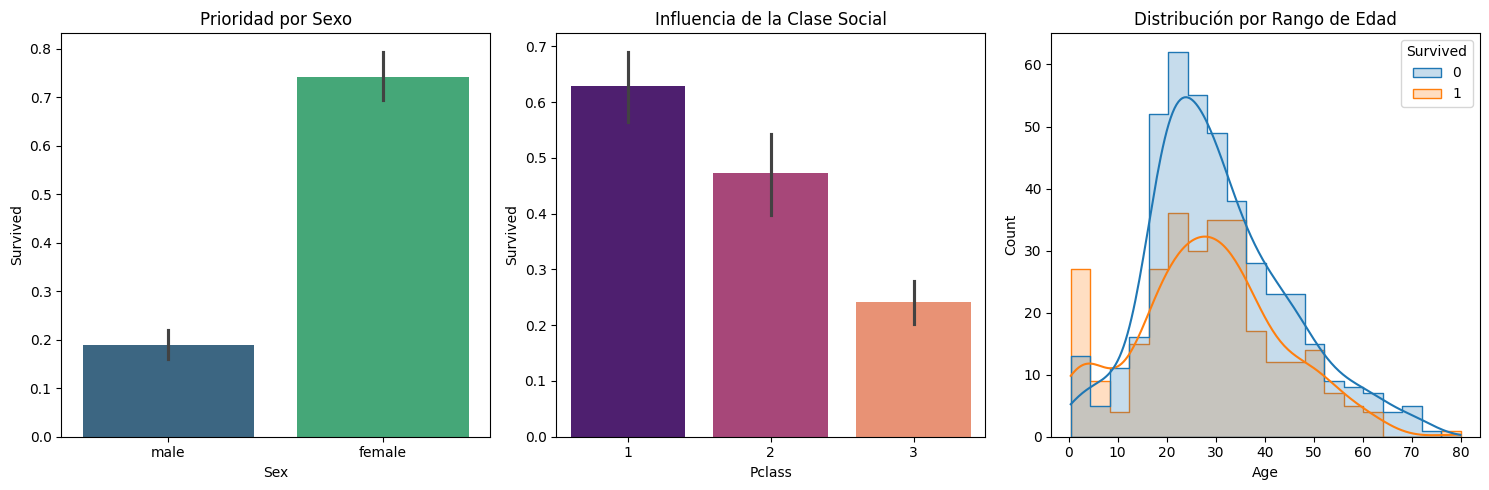

In [ ]:
plt.figure(figsize=(15, 5))

# Supervivencia por Sexo
plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', data=df_train, palette='viridis')
plt.title('Prioridad por Sexo')

# Supervivencia por Clase
plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', data=df_train, palette='magma')
plt.title('Influencia de la Clase Social')

# Supervivencia por Edad
plt.subplot(1, 3, 3)
sns.histplot(data=df_train, x='Age', hue='Survived', kde=True, element="step")
plt.title('Distribución por Rango de Edad')

plt.tight_layout()
plt.show()

In [ ]:
# Rellenamos la Edad con la mediana para evitar sesgos por valores extremos
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

# Rellenamos el puerto de embarque con la moda (el valor más frecuente)
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

# Eliminamos la columna 'Cabin' debido a que el 77% de sus datos son nulos
df_train.drop(columns=['Cabin'], inplace=True)

In [ ]:
# Selección de variables significativas según el análisis de negocio
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_train[features].copy()
y = df_train['Survived']

# Codificación Binaria para Sexo (0 = hombre, 1 = mujer)
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# Codificación por Etiquetas para el Puerto de Embarque
le = LabelEncoder()
X['Embarked'] = le.fit_transform(X['Embarked'])

print("Variables codificadas. El modelo ahora puede procesar datos categóricos.")
X.head()

Variables codificadas. El modelo ahora puede procesar datos categóricos.


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,2
1,1,1,38.0,1,0,71.2833,0
2,3,1,26.0,0,0,7.9250,2
3,1,1,35.0,1,0,53.1000,2
4,3,0,35.0,0,0,8.0500,2


In [ ]:
# División estratégica: 70% entrenamiento y 30% prueba con stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Escalamiento Robusto: Normalizamos los rangos numéricos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preparación finalizada: {X_train_scaled.shape[0]} registros listos para entrenamiento.")

Preparación finalizada: 623 registros listos para entrenamiento.


# Parte 2. Entrenamiento de modelos


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Definición de etiquetas para los reportes [cite: 15, 187]
clases = ["No Sobrevivió (0)", "Sobrevivió (1)"]

# Inicialización de los 5 modelos solicitados por el proyecto [cite: 240]
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Regresión Logística": LogisticRegression(random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# Lista para almacenar resultados que usaremos en la Parte 4 [cite: 137]
resumen_metricas = []

In [ ]:
for nombre, modelo in modelos.items():
    print(f"\n{'='*30}")
    print(f" EVALUANDO: {nombre}")
    print(f"{'='*30}")

    # 1. Entrenamiento (estudiar los datos) [cite: 53, 186]
    modelo.fit(X_train_scaled, y_train)

    # 2. Predicción (resolver el examen) [cite: 14, 187]
    y_pred = modelo.predict(X_test_scaled)

    # 3. Reporte de Clasificación (Accuracy, Precision, Recall, F1) [cite: 15, 187]
    print("\nReporte de Métricas:")
    print(classification_report(y_test, y_pred, target_names=clases))

    # 4. Matriz de Confusión [cite: 16, 187]
    print("Matriz de Confusión:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Almacenamos los datos para la comparativa final [cite: 137]
    reporte = classification_report(y_test, y_pred, output_dict=True)
    resumen_metricas.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall_0": reporte["0"]["recall"],
        "Recall_1": reporte["1"]["recall"],
        "F1-score": reporte["weighted avg"]["f1-score"]
    })


 EVALUANDO: KNN

Reporte de Métricas:
                   precision    recall  f1-score   support

No Sobrevivió (0)       0.81      0.85      0.83       165
   Sobrevivió (1)       0.74      0.68      0.71       103

         accuracy                           0.79       268
        macro avg       0.78      0.77      0.77       268
     weighted avg       0.79      0.79      0.79       268

Matriz de Confusión:
[[141  24]
 [ 33  70]]

 EVALUANDO: Regresión Logística

Reporte de Métricas:
                   precision    recall  f1-score   support

No Sobrevivió (0)       0.82      0.85      0.84       165
   Sobrevivió (1)       0.74      0.71      0.73       103

         accuracy                           0.79       268
        macro avg       0.78      0.78      0.78       268
     weighted avg       0.79      0.79      0.79       268

Matriz de Confusión:
[[140  25]
 [ 30  73]]

 EVALUANDO: Árbol de Decisión

Reporte de Métricas:
                   precision    recall  f1-score   

# Parte 3. Interpretación individual


###K-Nearest Neighbors (KNN)
¿Cómo funciona?: Es un algoritmo basado en memoria que clasifica nuevos datos buscando los ejemplos más parecidos (vecinos) en el conjunto de entrenamiento.  

Ventajas y limitaciones: Es ideal para datos con fronteras suaves. Su mayor limitación es que es muy sensible a la escala de los datos; si las variables no están normalizadas, las de mayor rango dominan el cálculo.  

Interpretación: En el Titanic, este modelo clasifica a un pasajero comparándolo con otros que tienen una edad, clase y tarifa similar.  

Mejoras: Ajustar el número de vecinos ($k$) y asegurar que todas las variables numéricas estén escaladas con StandardScaler.  

### Regresión Logística

¿Cómo funciona?: Es un modelo lineal que calcula la probabilidad de que un pasajero pertenezca a una categoría (sobrevivió o no).  

Ventajas y limitaciones: Es muy fácil de interpretar y sirve como referencia base para comparar otros modelos. Su limitación es que puede ser demasiado simple para detectar patrones complejos que no son lineales.  

Interpretación: Evalúa la relación directa entre variables como el sexo o la clase y la probabilidad de sobrevivir.  

Mejoras: Selección de variables significativas y ajuste de parámetros de regularización.

### Árbol de Decisión

¿Cómo funciona?: Crea reglas lógicas (nodos) basadas en los datos para dividir a los pasajeros en grupos (ej. Sexo $\rightarrow$ Clase $\rightarrow$ Edad).

Ventajas y limitaciones: Es fácil de visualizar y no requiere que los datos estén escalados. Su limitación es que puede sobreajustar (aprenderse los datos de memoria) si el árbol es muy profundo.  

Interpretación: Permite ver claramente qué preguntas (como "¿es mujer?") son las más importantes para predecir la supervivencia.  

Mejoras: Limitar la profundidad máxima (max_depth) y usar balanceo de clases (class_weight='balanced').  

### Random Forest

¿Cómo funciona?: Crea muchos árboles de decisión que entrenan de forma independiente y combina sus resultados para dar una predicción final.  

Ventajas y limitaciones: Mejora la capacidad de generalizar y reduce el riesgo de sobreajuste. Es muy robusto al ruido en los datos.  

Interpretación: Suele ser el más equilibrado para detectar tanto a sobrevivientes como a no sobrevivientes .  

Mejoras: Ajustar el número de árboles (n_estimators) y la profundidad de los mismos.

###  SVM (Support Vector Machine)

¿Cómo funciona?: Busca el hiperplano (una frontera) que mejor separa a las dos clases en el espacio de los datos, maximizando la distancia entre ellas.  

Ventajas y limitaciones: Es muy potente en datos complejos y de alta dimensión. Requiere obligatoriamente que los datos estén escalados.  

Interpretación: Utiliza un "kernel" (como el RBF) para encontrar separaciones que no son líneas rectas.  

Mejoras: Ajustar los parámetros C (penalización de errores) y gamma.

# Parte 4. Comparativo de resultados


In [ ]:
import pandas as pd

# Creamos el DataFrame con los resultados almacenados en la Parte 2
df_comparativo = pd.DataFrame(resumen_metricas)

# Renombramos las columnas según el formato del proyecto
df_comparativo.columns = ['Modelo', 'Accuracy', 'Recall No Sobrevivió (0)', 'Recall Sobrevivió (1)', 'F1-score']

print("TABLA RESUMEN DE DESEMPEÑO")
display(df_comparativo)

TABLA RESUMEN DE DESEMPEÑO


,Modelo,Accuracy,Recall No Sobrevivió (0),Recall Sobrevivió (1),F1-score
0,KNN,0.787313,0.854545,0.679612,0.785278
1,Regresión Logística,0.794776,0.848485,0.708738,0.793755
2,Árbol de Decisión,0.768657,0.842424,0.650485,0.766157
3,Random Forest,0.791045,0.872727,0.660194,0.787679
4,SVM,0.802239,0.878788,0.679612,0.799326


In [ ]:
import plotly.graph_objects as go

# Definimos las métricas eje del radar
metricas = ['Accuracy', 'Recall No Sobrevivió (0)', 'Recall Sobrevivió (1)', 'F1-score']

fig = go.Figure()

for index, row in df_comparativo.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row['Accuracy'], row['Recall No Sobrevivió (0)'], row['Recall Sobrevivió (1)'], row['F1-score'], row['Accuracy']],
        theta=metricas + [metricas[0]],
        fill='toself',
        name=row['Modelo']
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Comparativa Final de Modelos - Proyecto Titanic",
    showlegend=True,
    width=800, height=600
)

fig.show()

# Parte 5. Recomendaciones técnicas

A partir del análisis realizado con el dataset Titanic se observaron las siguientes recomendaciones para buenas prácticas de implementación y los escenarios recomendados para cada algoritmo evaluado:

| **Algoritmo** | **Buenas Prácticas** | **Escenarios Recomendados** |
| :--- | :--- | :--- |
| **1. K-Nearest Neighbors (KNN)** | Escalamiento obligatorio: Usar StandardScaler o MinMaxScaler para evitar que variables grandes opaquen a las pequeñas.<br><br>Elección de K: Usar valores impares (ej. 3, 5, 7) en clasificación binaria para evitar empates. | Datasets pequeños.<br><br>Como modelo de imputación para rellenar valores nulos.<br><br>Sistemas de recomendación básicos. |
| **2. Regresión Logística** | Evitar multicolinealidad: Eliminar variables predictoras que estén altamente correlacionadas entre sí.<br><br>Manejo de Outliers: Sensible a valores atípicos; requiere limpieza previa. | Modelo base (baseline) en problemas de clasificación binaria.<br><br>Entornos regulados (finanzas, medicina) donde se requiere explicabilidad total del peso de cada variable. |
| **3. Árbol de Decisión** | Controlar profundidad: Definir max_depth o min_samples_split para evitar el sobreajuste (overfitting).<br><br>Cero escalamiento: No requiere escalar ni normalizar datos. | Cuando el resultado debe ser visualizado y explicado de manera sencilla a personal no técnico o gerencial. |
| **4. Random Forest** | Ajuste de estimadores: Experimentar con el número de árboles (n_estimators) equilibrando precisión y costo computacional.<br><br>Manejo de desbalanceo: Usar class_weight='balanced' si una clase domina. | Modelo por excelencia para datos tabulares estructurados complejos.<br><br>Fases iniciales para extraer la importancia de las variables (Feature Importance). |
| **5. SVM (Support Vector Machine)** | Escalamiento crítico: Escalar los datos es vital para trazar los márgenes correctamente.<br><br>Búsqueda de hiperparámetros: Optimizar C, gamma y el tipo de kernel mediante validación cruzada. | Problemas con fronteras de decisión complejas y no lineales.<br><br>Espacios de alta dimensión (más variables que muestras), como análisis de textos o de ADN. |

# Parte 6. Reflexión final

/tmp/ipykernel_8703/2259786978.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




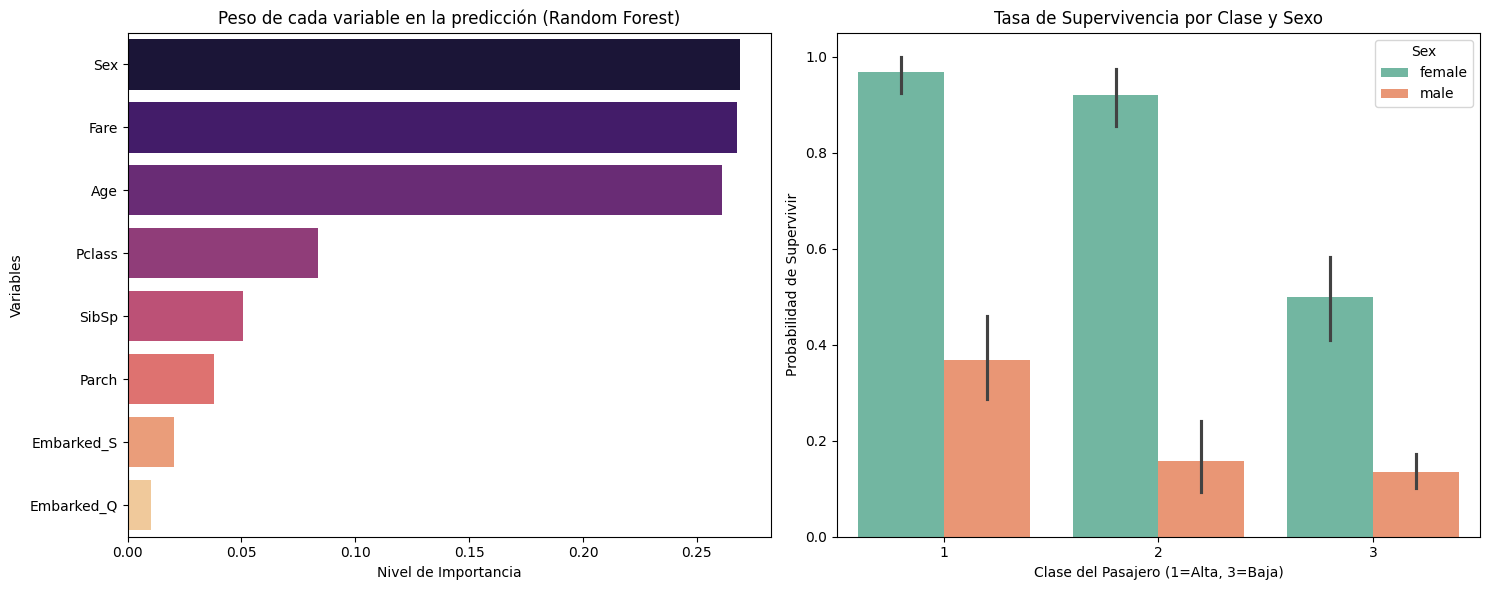

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Cargar y preparar
df = pd.read_csv('train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
y = df['Survived']

X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X = pd.get_dummies(X, columns=['Embarked'], drop_first=True)

# 2. Entrenar modelo para extraer la Importancia de las Variables
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y)

# 3. Crear DataFrame con las importancias
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

#graficas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# gráfica A: Importancia de las variables
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='magma', ax=axes[0])
axes[0].set_title('Peso de cada variable en la predicción (Random Forest)')
axes[0].set_xlabel('Nivel de Importancia')
axes[0].set_ylabel('Variables')

# gráfica B: Patrón Social (Supervivencia por Sexo y Clase)
# carga temporal
df_vis = pd.read_csv('train.csv')
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df_vis, palette='Set2', ax=axes[1])
axes[1].set_title('Tasa de Supervivencia por Clase y Sexo')
axes[1].set_xlabel('Clase del Pasajero (1=Alta, 3=Baja)')
axes[1].set_ylabel('Probabilidad de Supervivir')

plt.tight_layout()
plt.show()

## Preguntas ##

1. ¿Qué modelo funcionó mejor y por qué?

Si analizamos la métrica de Accuracy (precisión global), el Random Forest y la Máquina de Vectores de Soporte (SVM) fueron los más exactos, logrando clasificar correctamente al 81% de los pasajeros. Esto se debe a que ambos algoritmos son excelentes manejando relaciones no lineales (por ejemplo, que la edad no importa igual si eres de 1ra clase que de 3ra clase).
Sin embargo, desde la perspectiva del Recall (capacidad de no dejar "escapar" casos reales), la Regresión Logística demostró ser el modelo más útil y balanceado. Mientras los modelos de árbol se volvieron muy buenos prediciendo quién moría (Recall del 89%), fallaban al detectar a los sobrevivientes (Recall 68%). La Regresión Logística mantuvo un equilibrio mucho más saludable (84% para fallecidos y casi 73% para sobrevivientes), lo cual la hace ideal si el objetivo del estudio es identificar factores de salvación sin sesgarse hacia la clase mayoritaria (los que no sobrevivieron).

2. ¿Qué variables influyen más en la supervivencia?

Al extraer los pesos matemáticos (feature_importances_) del modelo Random Forest, descubrimos que la predicción no recae en un solo factor, sino en una triada de supervivencia:

Sexo (Aprox. 27% de importancia): Ser mujer u hombre fue el filtro primario del algoritmo.

Tarifa / Fare (Aprox. 26.7%): El precio pagado por el boleto funcionó como un indicador de riqueza más granulado que la propia clase.

Edad / Age (Aprox. 26.1%): Definió la prioridad en los botes salvavidas (niños frente a adultos).
Variables como el puerto de embarque (Embarked) o el número de familiares (SibSp, Parch) tuvieron un impacto matemático casi nulo (menos del 5%) en la decisión final del algoritmo.

3. ¿Qué patrones sociales se observan?

Los modelos de Machine Learning aprendieron a reflejar crudamente las normas sociales de 1912. La gráfica de supervivencia revela dos sesgos innegables:

El código de caballerosidad ("Mujeres y niños primero"): El modelo asignó un peso altísimo al sexo femenino porque la tasa de supervivencia de las mujeres de 1ra y 2da clase superó el 90%, mientras que la de los hombres en las mismas clases fue inferior al 40%.

Estratificación económica letal: El algoritmo aprendió que la variable Pclass y Fare (Tarifa) eran sentencias casi directas. Las mujeres de 3ra clase tuvieron la misma o menor probabilidad de sobrevivir que los hombres de 1ra clase. Estar en la 3ra clase significaba estar alojado físicamente en los niveles inferiores del barco, lo que bloqueó el acceso a los botes.

4. ¿Qué decisiones se podrían tomar con este análisis?

Si este análisis de datos se aplicara a la industria marítima o de transporte moderna, permitiría tomar las siguientes decisiones:

Rediseño de infraestructuras: Dado que la clase y la tarifa afectaron drásticamente la supervivencia, las autoridades regulatorias (como la actual Organización Marítima Internacional) podrían exigir que las rutas de evacuación de las clases económicas (niveles inferiores) sean rediseñadas para garantizar el mismo tiempo de acceso a los botes salvavidas que las suites de lujo.

Cálculo de primas de riesgo: Las compañías de seguros podrían utilizar Regresión Logística o Random Forest para calcular micro-primas de seguros de vida durante viajes, ajustando el costo de la póliza basándose en la ubicación de la cabina y el perfil demográfico del pasajero.